In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/cleaned_kaggle_v2.csv"

In [3]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.columns 

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Sleep_Hours',
       'Daily_Screen_Hours', 'Weekend_Screen_Hours', 'Social_Media_Hours',
       'Caffeine_Cups_Per_Day', 'Work_Productivity_Score', 'App_Usage_Count',
       'Exercise_Hours_Per_Week', 'Daily_Work_Hours', 'Commute_Hours_Per_Day',
       'Stress_Level', 'Stressed'],
      dtype='object')

<h3> Irrelevant Columns

In [5]:
irrelevant = ['User_ID', 'Weekend_Screen_Hours', 'Stress_Level']

In [6]:
df = df.drop(columns=irrelevant)

In [7]:
df.Stressed.value_counts()

Stressed
1    2544
0    1413
Name: count, dtype: int64

In [8]:
X = df.drop('Stressed', axis=1)
y = df['Stressed']

In [9]:
X = pd.get_dummies(X, drop_first=True)

<h3> Train Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

<h3> Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3> SVM Training 

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

svm_model = SVC(probability=True)

svm_model.fit(X_train_scaled, y_train)

SVC(probability=True)

In [13]:
y_pred_svm = svm_model.predict(X_test_scaled)

<h3> Model Evaluation 

In [14]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8484848484848485
              precision    recall  f1-score   support

           0       0.85      0.70      0.77       424
           1       0.85      0.93      0.89       764

    accuracy                           0.85      1188
   macro avg       0.85      0.82      0.83      1188
weighted avg       0.85      0.85      0.84      1188



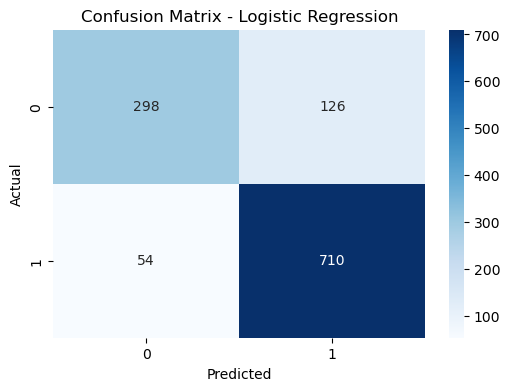

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [16]:
from sklearn.model_selection import cross_val_score
svm_scores = cross_val_score(
    svm_model, 
    X_train_scaled, 
    y_train, 
    cv=5)


print("GB CV Accuracy:", svm_scores.mean())

GB CV Accuracy: 0.8436248620912515


In [17]:
import joblib

joblib.dump(svm_model, "/Users/skush/CodeX/Stress-Level-Classifier/Models/svm_84.pkl")

['/Users/skush/CodeX/Stress-Level-Classifier/Models/svm_84.pkl']

<h3> Hyperparameter Tuning 

In [20]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

In [21]:
param_grid = {
    "C": [0.1, 1, 10, 50, 100],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", 0.01, 0.001, 0.0001],
    "class_weight": [None, "balanced"]
}

In [22]:
svm_model_ft = SVC(probability=True, random_state=42)

In [23]:
grid_search = GridSearchCV(
    svm_model_ft,
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 50, 100],
                         'class_weight': [None, 'balanced'],
                         'gamma': ['scale', 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'linear']},
             scoring='roc_auc', verbose=1)

In [24]:
print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 50, 'class_weight': None, 'gamma': 0.01, 'kernel': 'rbf'}


In [25]:
print("Best CV ROC-AUC:", grid_search.best_score_)

Best CV ROC-AUC: 0.889778625241752


In [26]:
best_svm = grid_search.best_estimator_

y_pred = best_svm.predict(X_test_scaled)
y_prob = best_svm.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy: 0.8442760942760943
ROC-AUC: 0.8791397066087129
              precision    recall  f1-score   support

           0       0.83      0.71      0.76       424
           1       0.85      0.92      0.88       764

    accuracy                           0.84      1188
   macro avg       0.84      0.81      0.82      1188
weighted avg       0.84      0.84      0.84      1188



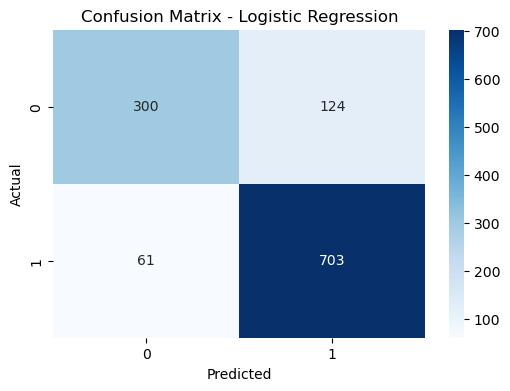

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()